# Advanced ML Models comparsion

## Import Library

In [23]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import Sci-kit Learn Modules

In [24]:
from sklearn.datasets import (
    make_classification,
    make_regression
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import (
     LogisticRegression,
     LinearRegression,
     Ridge,
     Lasso,
     ElasticNet
)
from sklearn.svm import (
     SVC,
     LinearSVC,
     SVR,
     LinearSVR,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
     accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

## Classification Comparison Code

### Creation of Classification dataset

In [25]:
x_cls, y_cls = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=10,
    n_redundant=5,
    n_classes=2,
    class_sep=1.2,
    random_state=42
)

### train and Test Split

In [26]:
X_cls_train, X_cls_test,y_cls_train,y_cls_test=train_test_split(
     x_cls,y_cls,
     test_size=0.25,
     stratify=y_cls,
     random_state=42
)

### Defining Classification Models

In [27]:
classification_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000))
    ]),

    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(max_iter=10000, random_state=42))
    ]),

    "SVC RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=1, gamma="scale"))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ),

    "Gaussian Naive Bayes": GaussianNB()
}

### Classification Evaluation Function

In [28]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    y_train_pred = model.predict(X_train)

    return {
        "model": name,
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "generalization_gap": (
            accuracy_score(y_train, y_train_pred)
            - accuracy_score(y_test, y_pred)
        ),
        "train_time_sec": train_time,
        "prediction_time_sec": pred_time
    }

### Run CLassification Comparison

In [29]:
classification_results = []

for name, model in classification_models.items():
    result = evaluate_classifier(
        name,
        model,
        X_cls_train,
        X_cls_test,
        y_cls_train,
        y_cls_test
    )
    classification_results.append(result)
classification_df = pd.DataFrame(classification_results)
classification_df = classification_df.sort_values(by="f1", ascending=False)
display(classification_df)

,model,train_accuracy,test_accuracy,precision,recall,f1,generalization_gap,train_time_sec,prediction_time_sec
2,SVC RBF,0.972444,0.944000,0.951087,0.935829,0.943396,0.028444,0.027615,0.014255
5,Random Forest,0.993778,0.936000,0.950276,0.919786,0.934783,0.057778,0.981730,0.034380
3,KNN,0.950222,0.933333,0.935484,0.930481,0.932976,0.016889,0.002436,0.015922
1,LinearSVC,0.883556,0.896000,0.902174,0.887701,0.894879,-0.012444,0.007911,0.001064
0,Logistic Regression,0.882667,0.890667,0.901099,0.877005,0.888889,-0.008000,0.015251,0.001129
4,Decision Tree,0.942222,0.861333,0.860963,0.860963,0.860963,0.080889,0.017902,0.000741
6,Gaussian Naive Bayes,0.838222,0.850667,0.896970,0.791444,0.840909,-0.012444,0.003000,0.000655


### Plot of graph

#### For all Metrics

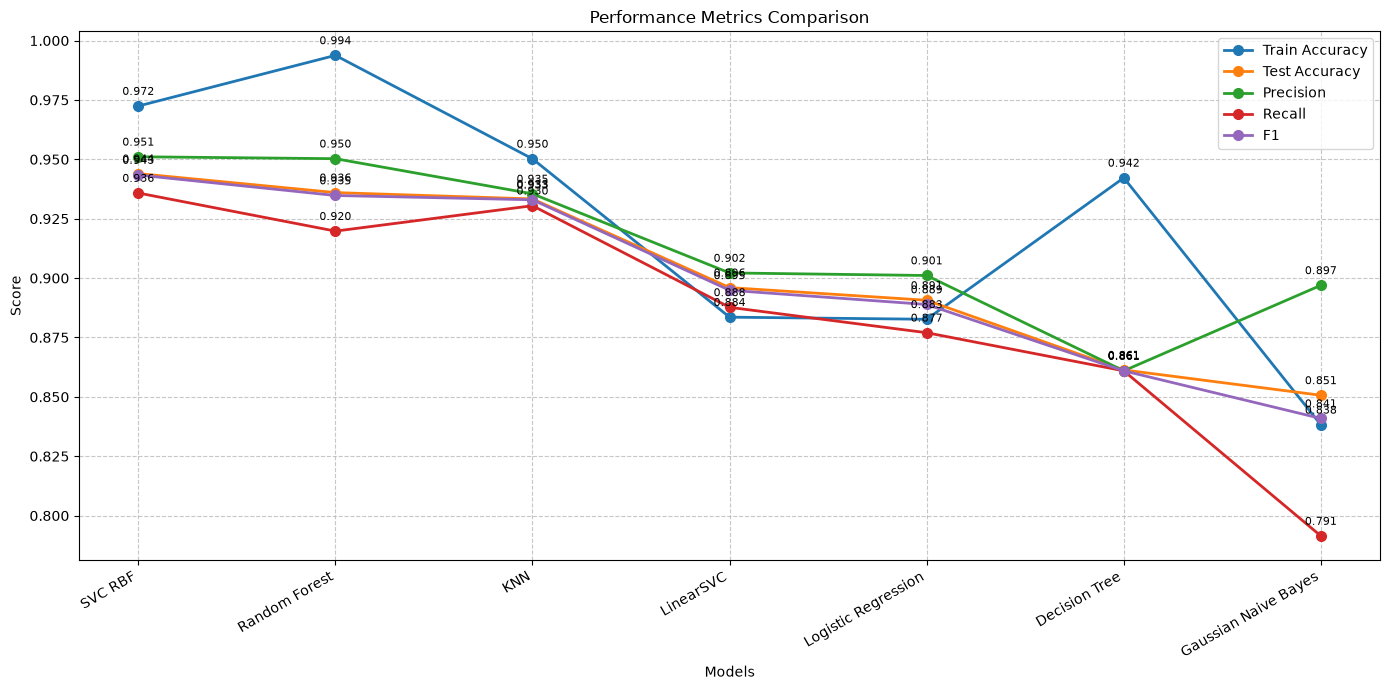

In [30]:
models = classification_df['model']
x = np.arange(len(models))
metrics = [
    'train_accuracy','test_accuracy',
    'precision','recall','f1'
]
fig, ax = plt.subplots(figsize=(14, 7))
for metric in metrics:
    y = classification_df[metric]
    ax.plot(
        x, y,
        marker='o',linewidth=2,
        markersize=7,label=metric.replace('_', ' ').title()
    )
    # Add value labels
    for i, value in enumerate(y):
        ax.annotate(
            f'{value:.3f}',(i, value),
            xytext=(0, 8),textcoords='offset points',
            ha='center',fontsize=8
        )
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_title('Performance Metrics Comparison')
ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

#### Generalisation Gap

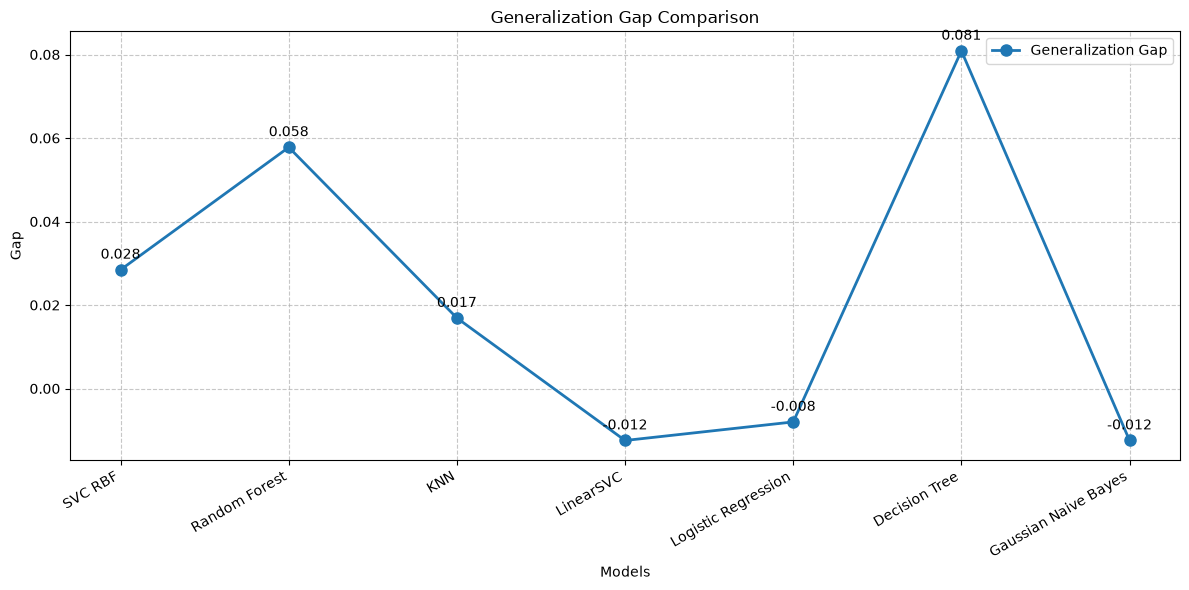

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
y = classification_df['generalization_gap']
ax.plot(
    x, y,marker='o',
    linewidth=2,markersize=8,
    label='Generalization Gap'
)
for i, value in enumerate(y):
    ax.annotate(
        f'{value:.3f}',(i, value),
        xytext=(0, 8),textcoords='offset points',
        ha='center'
    )
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_title('Generalization Gap Comparison')
ax.set_xlabel('Models')
ax.set_ylabel('Gap')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

#### Time Metrics Plot

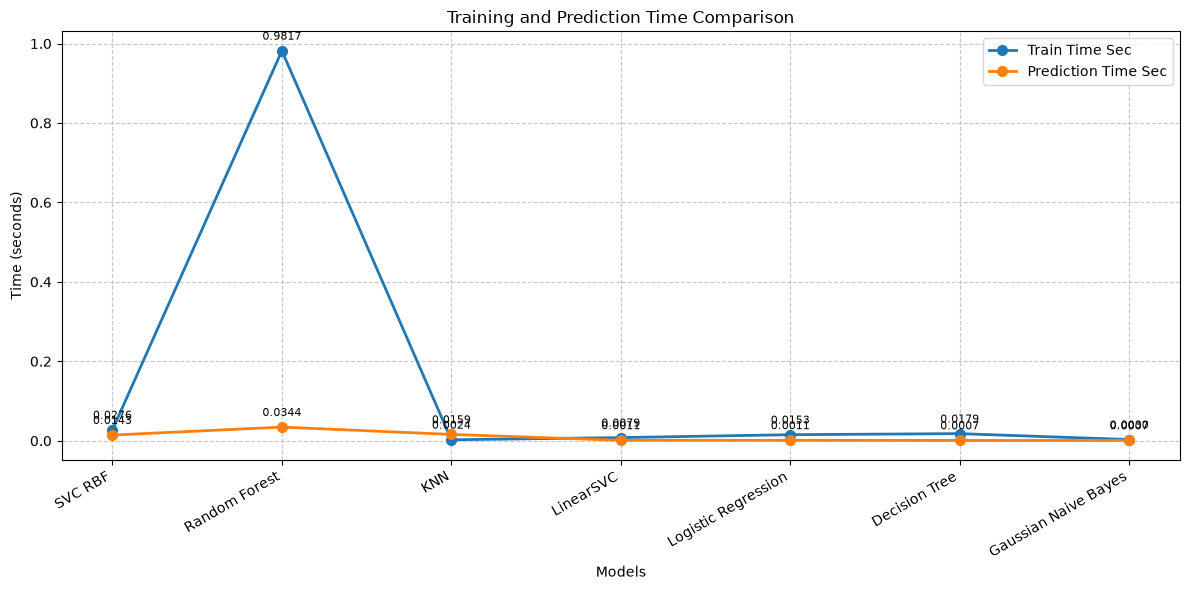

In [32]:
fig, ax = plt.subplots(figsize=(12, 6))
time_metrics = [
    'train_time_sec',
    'prediction_time_sec'
]
for metric in time_metrics:
    y = classification_df[metric]
    ax.plot(
        x, y,marker='o',
        linewidth=2,markersize=7,
        label=metric.replace('_', ' ').title()
    )
    for i, value in enumerate(y):
        ax.annotate(
            f'{value:.4f}',(i, value),
            xytext=(0, 8),textcoords='offset points',
            ha='center',fontsize=8
        )
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=30, ha='right')
ax.set_title('Training and Prediction Time Comparison')
ax.set_xlabel('Models')
ax.set_ylabel('Time (seconds)')
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend()
plt.tight_layout()
plt.show()

## Regressison Comparison Code

### Creation of Regression Datasets

In [33]:
X_reg, y_reg = make_regression(
    n_samples=1500,
    n_features=20,
    n_informative=10,
    noise=20,
    random_state=42
)

### Train and Test Split

In [34]:

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

### Defining Regression Models

In [ ]:
regression_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, max_iter=10000, random_state=42))
    ]),
    "ElasticNet": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(
            alpha=0.01,
            l1_ratio=0.5,
            max_iter=10000,
            random_state=42
        ))
    ]),
    "LinearSVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVR(
            C=1.0,
            epsilon=0.1,
            max_iter=20000,
            random_state=42
        ))
    ]),
    "SVR RBF": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(
            kernel="rbf",
            C=10,
            gamma="scale",
            epsilon=0.1
        ))
    ]),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42
    )
}

### Regression Evaluation Function

In [36]:
def evaluate_regressor(name, model, X_train, X_test, y_train, y_test):
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start_pred

    y_train_pred = model.predict(X_train)

    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    return {
        "model": name,
        "train_MAE": mean_absolute_error(y_train, y_train_pred),
        "test_MAE": mean_absolute_error(y_test, y_pred),
        "train_RMSE": train_rmse,
        "test_RMSE": test_rmse,
        "train_R2": r2_score(y_train, y_train_pred),
        "test_R2": r2_score(y_test, y_pred),
        "RMSE_gap": test_rmse - train_rmse,
        "train_time_sec": train_time,
        "prediction_time_sec": pred_time
    }

### Run regression Comparsion

In [ ]:
regression_results = []
for name, model in regression_models.items():
    result = evaluate_regressor(
        name,
        model,
        X_reg_train,
        X_reg_test,
        y_reg_train,
        y_reg_test
    )
    regression_results.append(result)
regression_df = pd.DataFrame(regression_results)
regression_df = regression_df.sort_values(by="test_RMSE")

display(regression_df)

,model,train_MAE,test_MAE,train_RMSE,test_RMSE,train_R2,test_R2,RMSE_gap,train_time_sec,prediction_time_sec
2,Lasso,15.749263,16.692214,19.867361,20.758957,0.988403,0.986662,0.891596,0.002464,0.000505
0,Linear Regression,15.750110,16.693237,19.867308,20.759958,0.988403,0.986660,0.892651,0.005564,0.000882
1,Ridge,15.749980,16.701596,19.867999,20.768204,0.988403,0.986650,0.900204,0.003860,0.000587
3,ElasticNet,15.760344,16.750367,19.889719,20.822959,0.988377,0.986579,0.933241,0.004320,0.000622
4,LinearSVR,16.022061,17.226391,20.407476,21.454573,0.987764,0.985753,1.047096,0.003932,0.000480
5,SVR RBF,54.989585,58.853353,78.550177,79.291938,0.818720,0.805398,0.741761,0.059783,0.033467
7,Random Forest Regressor,38.526394,69.433078,47.650160,90.651210,0.933291,0.745648,43.001049,2.226952,0.043639
6,Decision Tree Regressor,73.379377,104.048044,92.543371,131.856861,0.748379,0.461861,39.313489,0.014347,0.000537


### Plot of Graphs

#### For all metrics

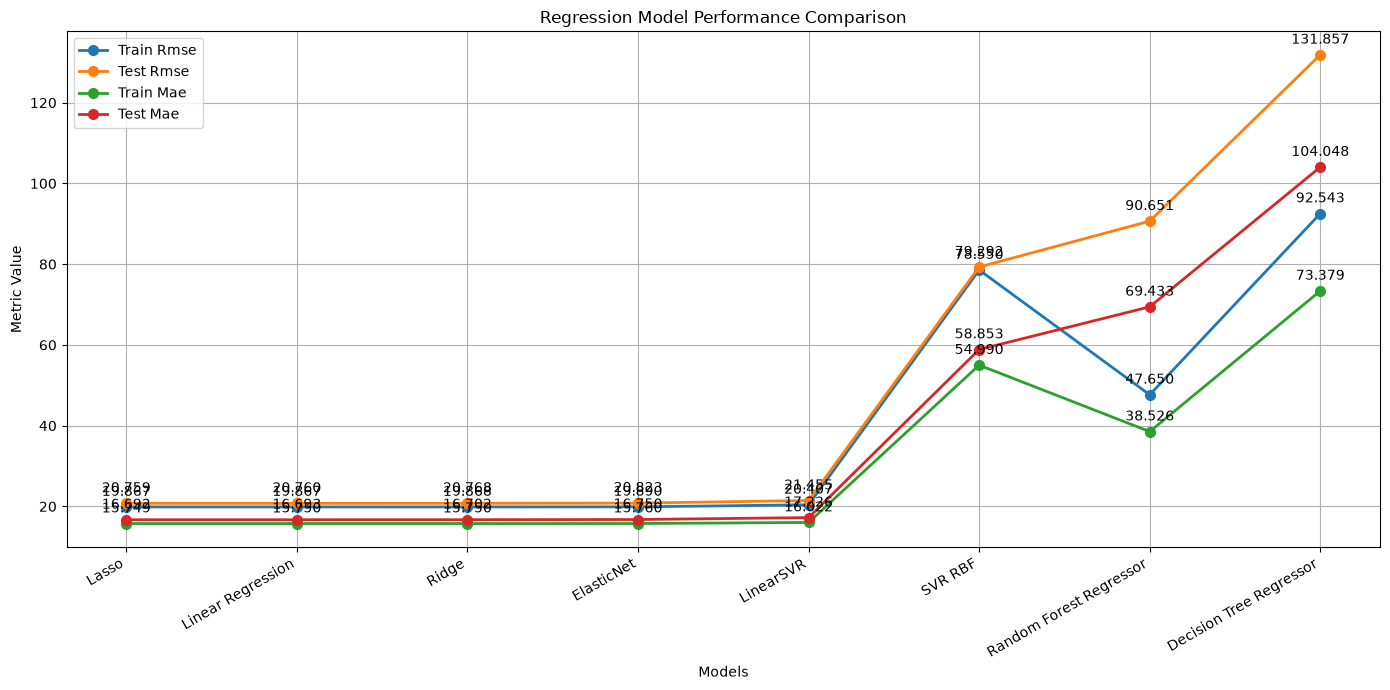

In [ ]:
models = regression_df["model"]
x = np.arange(len(models))
metrics = [
    "train_RMSE","test_RMSE",
    "train_MAE","test_MAE","R2"
]
fig, ax = plt.subplots(figsize=(14,7))
for metric in metrics:
    if metric in regression_df.columns:
        y = regression_df[metric]
        ax.plot(
            x,y,marker="o",
            linewidth=2,markersize=7,
            label=metric.replace("_"," ").title()
        )
        for i,value in enumerate(y):
            ax.annotate(
                f"{value:.3f}",(i,value),
                xytext=(0,8),textcoords="offset points",
                ha="center"
            )
ax.set_xticks(x)
ax.set_xticklabels(
    models,rotation=30,ha="right"
)
ax.set_title("Regression Model Performance Comparison")
ax.set_xlabel("Models")
ax.set_ylabel("Metric Value")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

#### For Generalization gap Analysis

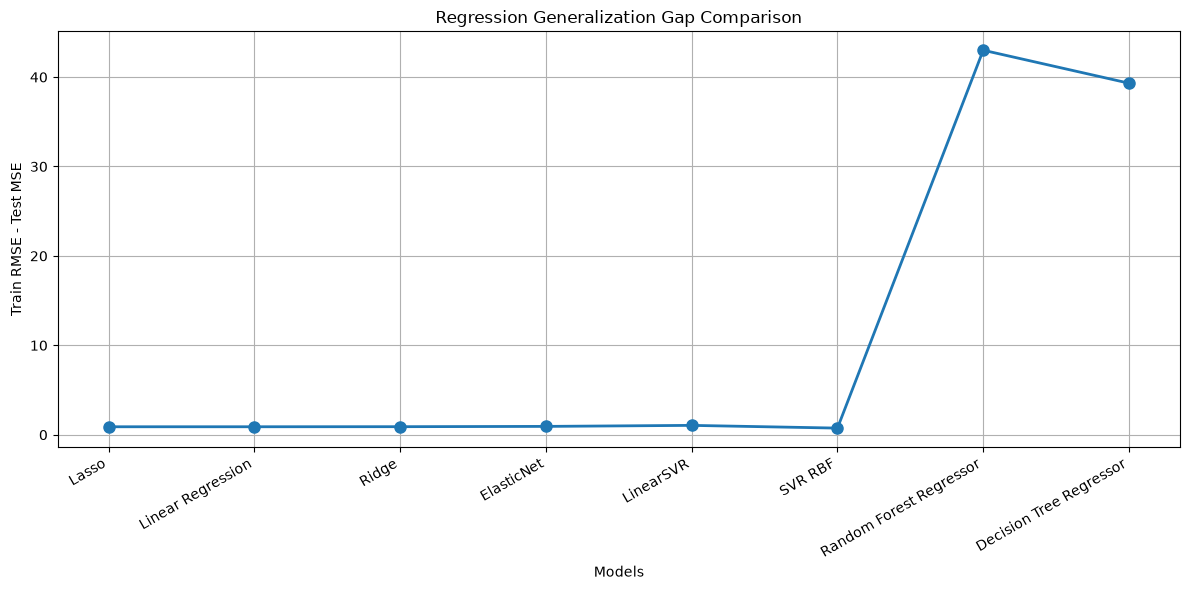

In [39]:
fig,ax=plt.subplots(figsize=(12,6))
gap=regression_df["RMSE_gap"]
ax.plot(x,gap,
     marker="o",linewidth=2,markersize=8
)
for i,val in enumerate(gap):
     ax.annotate(
        f"{value:.3f}",
        (i,value),
        xytext=(0,8),
        textcoords="offset points",
        ha="center"
    )
ax.set_xticks(x)
ax.set_xticklabels(
     models,rotation=30,ha="right"
)
ax.set_title(
     "Regression Generalization Gap Comparison"
)
ax.set_xlabel("Models")
ax.set_ylabel(
    "Train RMSE - Test MSE"
)
ax.grid(True)
plt.tight_layout()
plt.show()

#### Time metrics

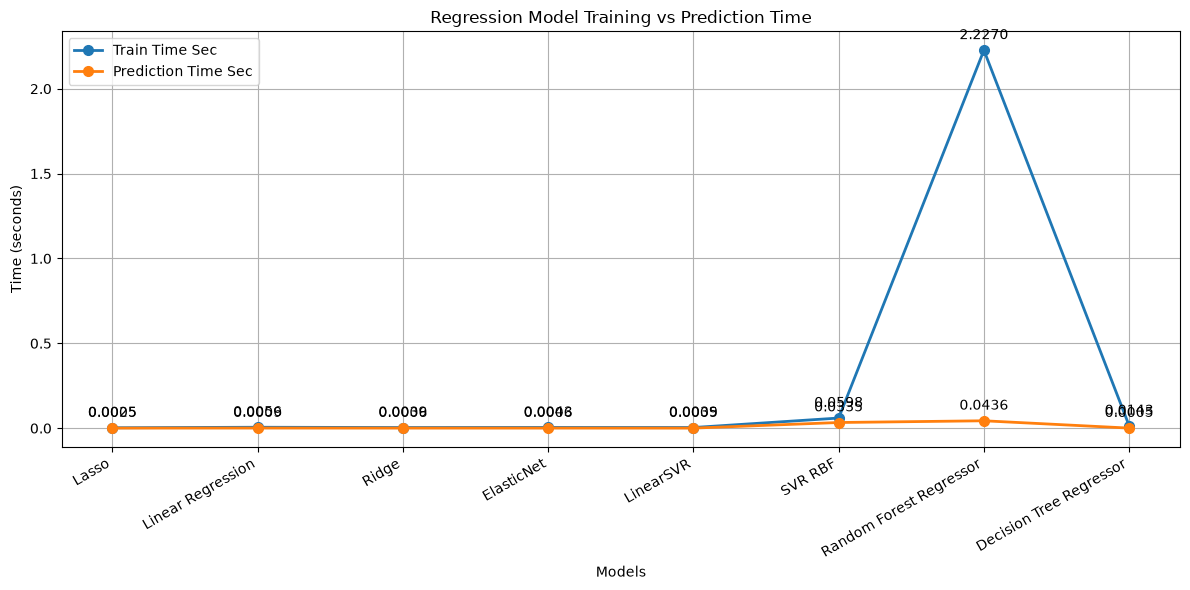

In [ ]:
time_metrics = [
    "train_time_sec",
    "prediction_time_sec"
]
fig, ax = plt.subplots(figsize=(12,6))
for metric in time_metrics:
    y = regression_df[metric]
    ax.plot(
        x,y,marker="o",
        linewidth=2,markersize=7,
        label=metric.replace("_"," ").title()
    )
    for i,value in enumerate(y):
        ax.annotate(
            f"{value:.4f}",(i,value),
            xytext=(0,8),textcoords="offset points",
            ha="center"
        )
ax.set_xticks(x)
ax.set_xticklabels(
    models,rotation=30,
    ha="right")
ax.set_title("Regression Model Training vs Prediction Time")
ax.set_xlabel("Models")
ax.set_ylabel("Time (seconds)")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()